# Phase-shear MLE: systematic bias, differential cancellation, and correction — 1e6 vs 1e8 atoms

For each shot, `phase_shear_fit.py` fits a Gaussian x fringe model directly to the
ground-state port image (no PSMAP used here — this is a direct image-space MLE,
unlike the theta/beta pipeline in `map_inference.py`) at both Z0 and Z100, giving
a per-shot phase estimate `phi_0_fit` plus fitted cloud-shape parameters (mu_x, mu_y,
sig_x, sig_y, kappa_x, kappa_y, gamma_x, gamma_y). `phi_0_fit` is dominated by the
random per-shot laser phase (std ~ pi), but carries a smaller systematic offset that
depends on the cloud's actual position/shape on the fringe pattern (wavefront-averaging
effect). The differential Z100-Z0 phase cancels the shared random laser phase and
isolates the signal `delta_phi = As*sin(2*pi*f*i) + Ac*cos(2*pi*f*i)`, but the
systematic does NOT fully cancel and must be regressed out.

**This notebook, run apples-to-apples at matched shot count for two atom counts
(1e6, 1e8):**
1. Data available: both datasets are the `..._kappa3.14e+04_both` runs (linear phase
   gradient applied at both AIs), 20 runs x 20 shots (kept small intentionally — see
   below), same true signal (As=0.0878, Ac=0.0479, f=0.3).
2. Extract the systematic bias (offset/gradient/curvature vs cloud-shear params) and
   visualise it (heatmaps + a 3D surface vs the two most informative features).
3. Remove it via polynomial regression on the **fitted** cloud-shear parameters
   (the practically available correction).
4. Compare against the same regression using the **true** initial kinematics as
   regressors (oracle: what if we knew the cloud's real position/width exactly,
   with zero measurement error?) — evaluated **in-sample**, since the point of the
   oracle case is "how good is the correction if you already know the true params",
   not out-of-sample generalisation.

Note on sample size: this run uses only 20 shots/run (fast turnaround) rather than
the full 200 — enough to see the effect sizes, but small enough that a full
16-feature degree-2 polynomial overfits badly (out-of-sample R^2 goes negative).
We use a **degree-1 (linear)** systematic model here for numerical stability; the
full 200-shot/run sweep (already available for 1e6 in `results/phase_shear_1e6/`)
supports a degree-2 fit with meaningfully higher R^2 (~0.46) — re-run with more
shots for a final paper-quality version.

In [2]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3d projection)
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

REPO = Path('..').resolve()
N_SHOTS_USE = 20   # apples-to-apples shot count for both datasets (see note above)
F_SIG = 0.3

DATASETS = {
    '1e6': REPO / 'results' / 'phase_shear_1e6',
    '1e8': REPO / 'results' / 'phase_shear_1e8',
}
DATASET_LABELS = {'1e6': r'$10^6$ atoms', '1e8': r'$10^8$ atoms'}
DATASET_COLORS = {'1e6': 'steelblue', '1e8': 'darkorange'}

FIT_FEATS  = ['mu_x', 'mu_y', 'sig_x2', 'sig_y2', 'kappa_x_c', 'kappa_y', 'gamma_x', 'gamma_y']
TRUE_FEATS = ['mu_x0', 'mu_y0', 'mu_vx0', 'mu_vy0', 'sigma_x', 'sigma_y', 'sigma_vx', 'sigma_vy']
KAPPA_X_NOMINAL = 31400.0


def load_dataset(shear_dir, max_shots=None):
    """Flatten all phase_shear_run_*.pkl in shear_dir into one long DataFrame
    (one row per shot per AI), keeping both the fitted cloud-shear params and
    the true simulated kinematics for that shot."""
    records = []
    pkls = sorted(Path(shear_dir).glob('phase_shear_run_*.pkl'))
    meta0 = None
    for pkl in pkls:
        run_idx = int(pkl.stem.split('_')[-1])
        with open(pkl, 'rb') as f:
            d = pickle.load(f)
        if meta0 is None:
            meta0 = d
        for row in d['rows']:
            if max_shots is not None and row['shot'] >= max_shots:
                continue
            for ai, fkey, tkey in [('z0', 'fit_z0', 'theta_true_z0'),
                                    ('z100', 'fit_z100', 'theta_true_z100')]:
                fit, true = row[fkey], row[tkey]
                rec = dict(run=run_idx, shot=row['shot'], ai=ai,
                           phi_0_fit=fit['phi_0'], phi_0_true=true['phi0'],
                           delta_phi_true=row['delta_phi_true'],
                           mu_x=fit['mu_x'], mu_y=fit['mu_y'],
                           sig_x2=fit['sig_x']**2, sig_y2=fit['sig_y']**2,
                           kappa_x=fit['kappa_x'], kappa_y=fit['kappa_y'],
                           gamma_x=fit['gamma_x'], gamma_y=fit['gamma_y'],
                           C=fit['C'], success=fit['success'])
                for k in TRUE_FEATS:
                    rec[f'true_{k}'] = true[k]
                records.append(rec)
    df = pd.DataFrame(records)
    df = df[df['success']].copy()
    df['kappa_x_c'] = df['kappa_x'] - KAPPA_X_NOMINAL
    df['As_true'], df['Ac_true'] = meta0['As_true'], meta0['Ac_true']
    return df


dfs = {key: load_dataset(path, max_shots=N_SHOTS_USE) for key, path in DATASETS.items()}
for key, df in dfs.items():
    n_runs = df['run'].nunique(); n_shots = df[df.ai == 'z0']['shot'].nunique()
    print(f'{key}: {n_runs} runs x {n_shots} shots  ({len(df)} rows, success rate '
          f'{len(df)/(n_runs*n_shots*2)*100:.1f}%)')
print(f'\nTrue signal (shared): As={dfs["1e6"]["As_true"].iloc[0]:.4f}  '
      f'Ac={dfs["1e6"]["Ac_true"].iloc[0]:.4f}  f={F_SIG}')

1e6: 20 runs x 20 shots  (779 rows, success rate 97.4%)
1e8: 20 runs x 20 shots  (782 rows, success rate 97.8%)

True signal (shared): As=0.0878  Ac=0.0479  f=0.3


## 1. Sanity check: $\phi_0^{\rm fit} \approx -\phi_0^{\rm true} + C_{AI}$

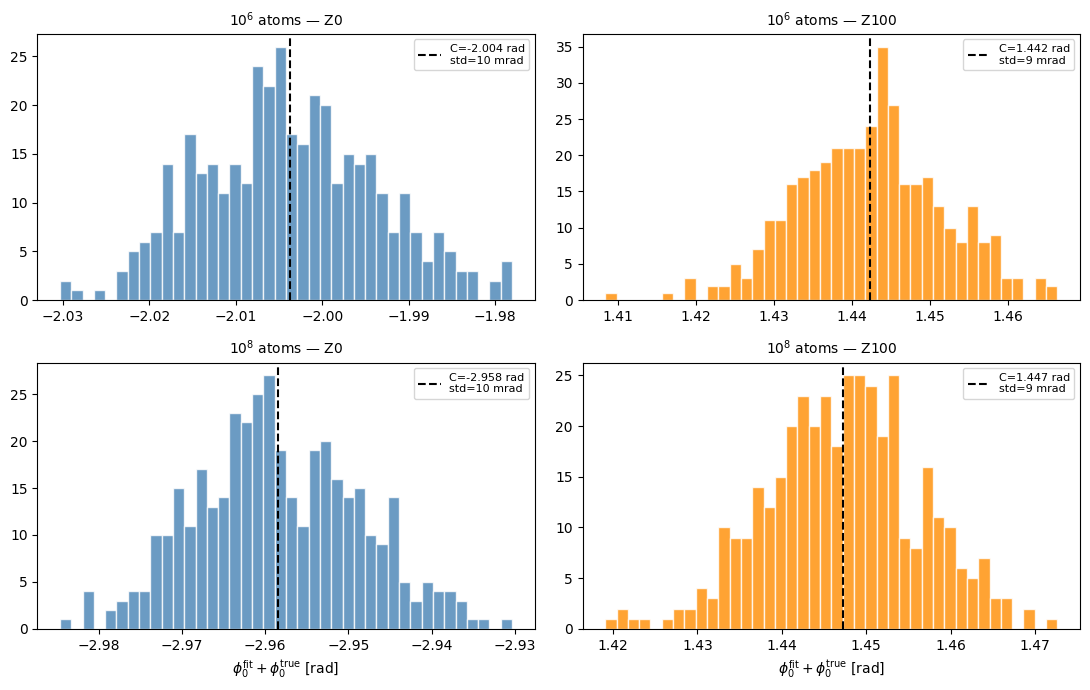

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row_i, key in enumerate(['1e6', '1e8']):
    df = dfs[key]
    for col_i, (ai, color) in enumerate([('z0', 'steelblue'), ('z100', 'darkorange')]):
        ax = axes[row_i, col_i]
        sub = df[df['ai'] == ai]
        raw_sum = (sub['phi_0_fit'] + sub['phi_0_true']).values
        mean_angle = np.angle(np.exp(1j * raw_sum).mean())   # proper circular mean
        circ = ((raw_sum - mean_angle + np.pi) % (2*np.pi)) - np.pi + mean_angle
        ax.hist(circ, bins=40, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(circ.mean(), color='k', lw=1.5, ls='--',
                   label=f'C={circ.mean():.3f} rad\nstd={circ.std()*1e3:.0f} mrad')
        ax.set_title(f'{DATASET_LABELS[key]} — {ai.upper()}', fontsize=10)
        ax.legend(fontsize=8)
        if row_i == 1: ax.set_xlabel(r'$\phi_0^{\rm fit}+\phi_0^{\rm true}$ [rad]')
plt.tight_layout(); plt.show()

## 2. For fun: absolute (noisy) vs differential (much less noisy) phase — one run

Each AI's fitted phase is dominated by the random per-shot laser phase (std ~ pi,
essentially uniform). Because both AIs share the same laser shot, Z100-Z0 cancels
almost all of that randomness and leaves mostly the (much smaller) signal + systematic.

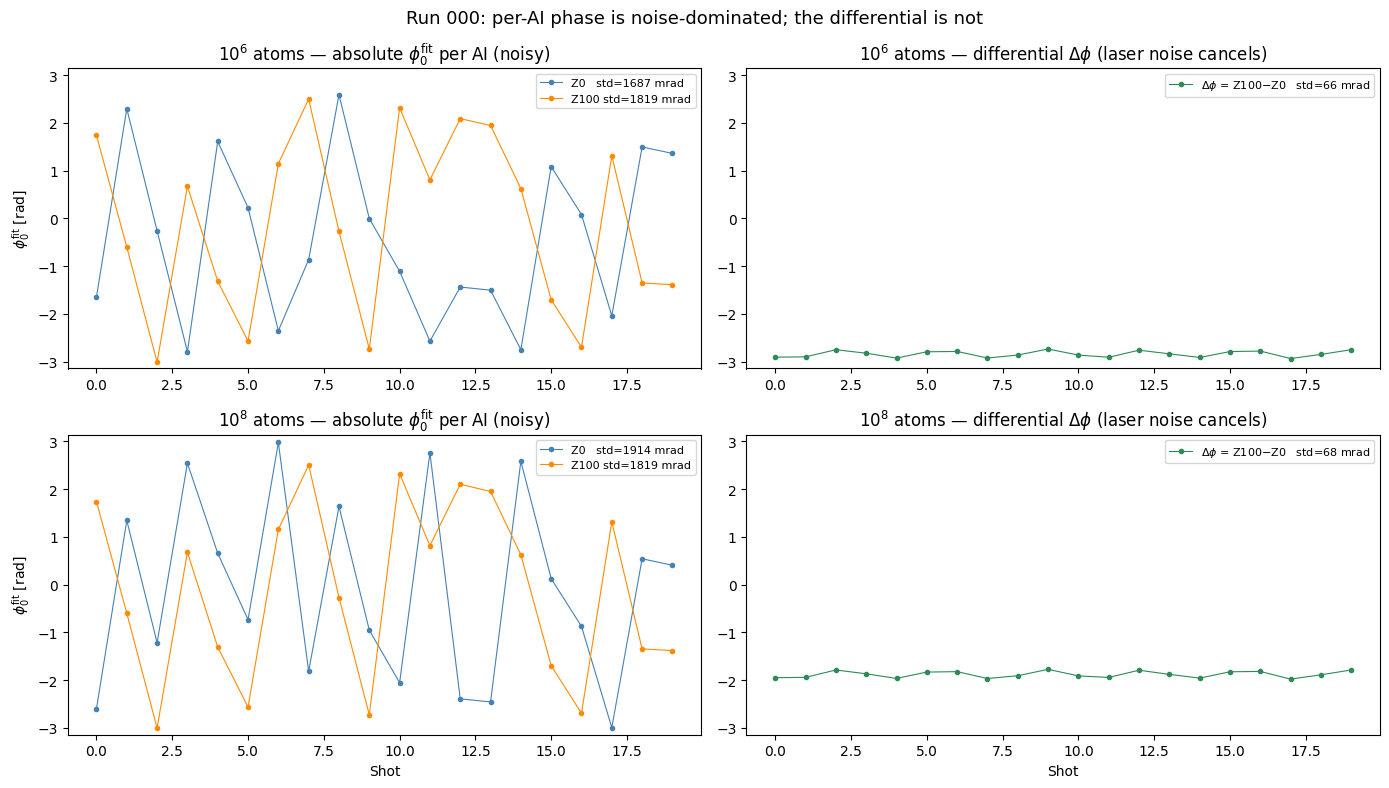

In [11]:
RUN_VIS = 0
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row_i, key in enumerate(['1e6', '1e8']):
    df = dfs[key]
    sub0 = df[(df.run == RUN_VIS) & (df.ai == 'z0')].sort_values('shot')
    sub1 = df[(df.run == RUN_VIS) & (df.ai == 'z100')].sort_values('shot')
    shots = sub0['shot'].values
    phi_z0, phi_z100 = sub0['phi_0_fit'].values, sub1['phi_0_fit'].values
    dphi_raw = phi_z100 - phi_z0
    mean_angle = np.angle(np.exp(1j*dphi_raw).mean())
    dphi_circ = ((dphi_raw - mean_angle + np.pi) % (2*np.pi)) - np.pi + mean_angle

    ax = axes[row_i, 0]
    ax.plot(shots, phi_z0,  'o-', color='steelblue', ms=3, lw=0.8, label=f'Z0   std={phi_z0.std()*1e3:.0f} mrad')
    ax.plot(shots, phi_z100,'o-', color='darkorange', ms=3, lw=0.8, label=f'Z100 std={phi_z100.std()*1e3:.0f} mrad')
    ax.set_title(rf'{DATASET_LABELS[key]} — absolute $\phi_0^{{\rm fit}}$ per AI (noisy)')
    ax.set_ylabel(r'$\phi_0^{\rm fit}$ [rad]'); ax.legend(fontsize=8)

    ax.set_ylim([-np.pi, np.pi])

    ax = axes[row_i, 1]
    ax.plot(shots, dphi_circ, 'o-', color='seagreen', ms=3, lw=0.8,
            label=rf'$\Delta\phi$ = Z100$-$Z0   std={dphi_circ.std()*1e3:.0f} mrad')
    ax.set_title(rf'{DATASET_LABELS[key]} — differential $\Delta\phi$ (laser noise cancels)')
    ax.legend(fontsize=8)

    ax.set_ylim([-np.pi, np.pi])
    if row_i == 1:
        axes[row_i,0].set_xlabel('Shot'); axes[row_i,1].set_xlabel('Shot')
plt.suptitle(f'Run {RUN_VIS:03d}: per-AI phase is noise-dominated; the differential is not', fontsize=13)
plt.tight_layout(); plt.show()

## 3. Correlation scan: fitted $\phi_0$ vs cloud-shear parameters

Single-AI $\phi_0^{\rm fit}$ variance is dominated by the random laser phase, so any
systematic correlation with cloud params is small (R^2 will be tiny) — this is expected
and is exactly why the differential (Section 5) is the quantity we actually correct.

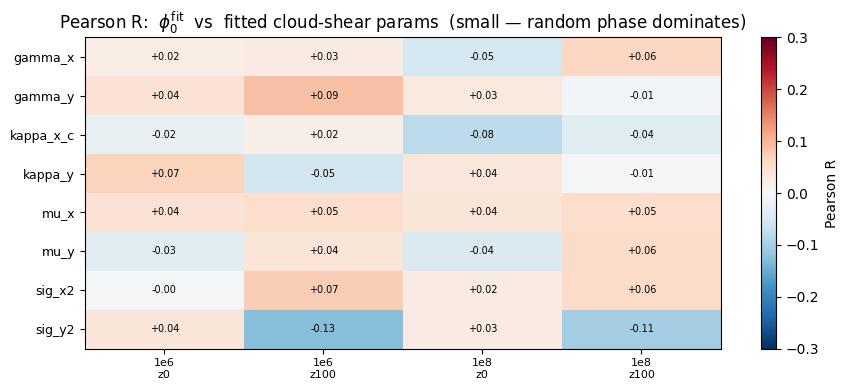

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
rows = []
for key in ['1e6', '1e8']:
    df = dfs[key]
    for ai in ['z0', 'z100']:
        sub = df[df.ai == ai]
        for feat in FIT_FEATS:
            r, _ = pearsonr(sub[feat].values, sub['phi_0_fit'].values)
            rows.append(dict(dataset=key, ai=ai, feat=feat, r=r))
R_df = pd.DataFrame(rows)
piv = R_df.pivot_table(index='feat', columns=['dataset', 'ai'], values='r')
im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f'{a}\n{b}' for a,b in piv.columns], fontsize=8)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f'{piv.values[i,j]:+.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson R')
ax.set_title(r'Pearson R:  $\phi_0^{\rm fit}$  vs  fitted cloud-shear params  (small — random phase dominates)')
plt.tight_layout(); plt.show()

## 4. Differential-phase ($\Delta\phi$ = Z100 $-$ Z0) systematic: extraction and removal

This is the correction that actually matters for signal recovery. Pipeline:
1. Circularly centre $\Delta\phi$ (it can wrap).
2. Partial out the known sinusoidal signal template first (so the regression can't
   accidentally absorb real signal).
3. Fit a degree-1 polynomial (linear, given the small 20-shot sample — see intro) of
   the detrended residual on cloud-shear features from both AIs.
4. Leave-one-run-out CV to check the correction generalises (not just overfitting).

In [6]:
def build_diff_df(df):
    base = ['run', 'shot', 'phi_0_fit', 'delta_phi_true'] + FIT_FEATS + [f'true_{k}' for k in TRUE_FEATS]
    z0   = df[df.ai == 'z0'][base].rename(columns={c: c+'_z0'   for c in base if c not in ('run', 'shot', 'delta_phi_true')})
    z100 = df[df.ai == 'z100'][[c for c in base if c != 'delta_phi_true']].rename(
             columns={c: c+'_z100' for c in base if c not in ('run', 'shot', 'delta_phi_true')})
    diff = z0.merge(z100, on=['run', 'shot'])
    diff['dphi_raw'] = diff['phi_0_fit_z100'] - diff['phi_0_fit_z0']
    mean_angle = np.angle(np.exp(1j * diff['dphi_raw'].values).mean())
    diff['dphi_circ'] = ((diff['dphi_raw'] - mean_angle + np.pi) % (2*np.pi)) - np.pi + mean_angle
    return diff


def differential_pipeline(diff, feat_cols, f_sig=F_SIG, label='', degree=1, alpha=1e-2, do_cv=True):
    """Partial out the known signal, regress the residual on feat_cols (degree-N
    polynomial, Ridge-regularised), optionally leave-one-run-out CV. Returns the
    augmented DataFrame plus a diagnostics dict."""
    shots = diff['shot'].values
    A = np.column_stack([np.sin(2*np.pi*f_sig*shots), np.cos(2*np.pi*f_sig*shots)])
    y = diff['dphi_circ'].values
    sig_coefs, *_ = np.linalg.lstsq(A, y, rcond=None)
    y_det = y - A @ sig_coefs

    X = diff[feat_cols].values
    pipe = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree, include_bias=True), Ridge(alpha=alpha))
    pipe.fit(X, y_det)
    y_pred = pipe.predict(X)
    R2_is = 1 - np.sum((y_det - y_pred)**2) / np.sum((y_det - y_det.mean())**2)

    out = diff.copy()
    out['dphi_pred'] = y_pred
    out['dphi_corr'] = y - y_pred
    out['est_raw']  = -(out['dphi_circ'] - out['dphi_circ'].mean())
    out['est_corr'] = -(out['dphi_corr'] - out['dphi_corr'].mean())
    out['res_raw']  = (out['est_raw']  - out['delta_phi_true']).values
    out['res_corr'] = (out['est_corr'] - out['delta_phi_true']).values

    diag = dict(R2_is=R2_is, R2_oos=None, pipe=pipe, feat_cols=feat_cols)
    if do_cv:
        runs = sorted(diff['run'].unique())
        oos_pred = np.full(len(diff), np.nan)
        for held in runs:
            tr, te = diff['run'] != held, diff['run'] == held
            shots_tr = diff.loc[tr, 'shot'].values
            A_tr = np.column_stack([np.sin(2*np.pi*f_sig*shots_tr), np.cos(2*np.pi*f_sig*shots_tr)])
            y_tr = diff.loc[tr, 'dphi_circ'].values
            sc_tr, *_ = np.linalg.lstsq(A_tr, y_tr, rcond=None)
            det_tr = y_tr - A_tr @ sc_tr
            pcv = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree, include_bias=True), Ridge(alpha=alpha))
            pcv.fit(diff.loc[tr, feat_cols].values, det_tr)
            oos_pred[te.values] = pcv.predict(diff.loc[te, feat_cols].values)
        R2_oos = 1 - np.sum((y_det - oos_pred)**2) / np.sum((y_det - y_det.mean())**2)
        out['dphi_oos_pred'] = oos_pred
        out['dphi_oos_corr'] = y - oos_pred
        out['est_oos_corr']  = -(out['dphi_oos_corr'] - out['dphi_oos_corr'].mean())
        out['res_oos_corr']  = (out['est_oos_corr'] - out['delta_phi_true']).values
        diag['R2_oos'] = R2_oos

    msg = f'[{label:24s}] R2_is={R2_is:.3f}'
    if do_cv: msg += f'  R2_oos={R2_oos:.3f}'
    msg += f'   std[mrad]: raw={out.res_raw.std()*1e3:5.2f}  corr(IS)={out.res_corr.std()*1e3:5.2f}'
    if do_cv: msg += f'  corr(OOS)={out.res_oos_corr.std()*1e3:5.2f}'
    print(msg)
    return out, diag


FIT_FEAT_COLS    = [c + '_z0' for c in FIT_FEATS]  + [c + '_z100' for c in FIT_FEATS]
ORACLE_FEAT_COLS = [f'true_{k}_z0' for k in TRUE_FEATS] + [f'true_{k}_z100' for k in TRUE_FEATS]

diffs, fit_results, oracle_results = {}, {}, {}
for key in ['1e6', '1e8']:
    diffs[key] = build_diff_df(dfs[key])
    print(f'--- {DATASET_LABELS[key]} ---')
    fit_results[key], _    = differential_pipeline(diffs[key], FIT_FEAT_COLS,    label=f'{key} fitted-features', degree=1, do_cv=True)
    # Oracle: in-sample only -- the point is "how good if you already KNOW the true params", not OOS generalisation.
    oracle_results[key], _ = differential_pipeline(diffs[key], ORACLE_FEAT_COLS, label=f'{key} true-kinematics (oracle)', degree=1, do_cv=False)
    print()

--- $10^6$ atoms ---
[1e6 fitted-features     ] R2_is=0.151  R2_oos=0.080   std[mrad]: raw=13.84  corr(IS)= 6.65  corr(OOS)= 7.22
[1e6 true-kinematics (oracle)] R2_is=0.149   std[mrad]: raw=13.84  corr(IS)= 7.07

--- $10^8$ atoms ---
[1e8 fitted-features     ] R2_is=0.882  R2_oos=0.862   std[mrad]: raw=13.51  corr(IS)= 1.18  corr(OOS)= 1.85
[1e8 true-kinematics (oracle)] R2_is=0.884   std[mrad]: raw=13.51  corr(IS)= 1.08



## 5. Visualising the extracted systematic: 3D surface + heatmap vs binned data

Shown for the fitted-feature model against its two most correlated predictors
(`mu_x_z0`, `mu_x_z100` — the cloud centroid position at each AI, by far the
dominant drivers per the physics: wavefront-averaging systematic ~ kappa*mu_x).

[1e6 fitted (diag only)  ] R2_is=0.151   std[mrad]: raw=13.84  corr(IS)= 6.65


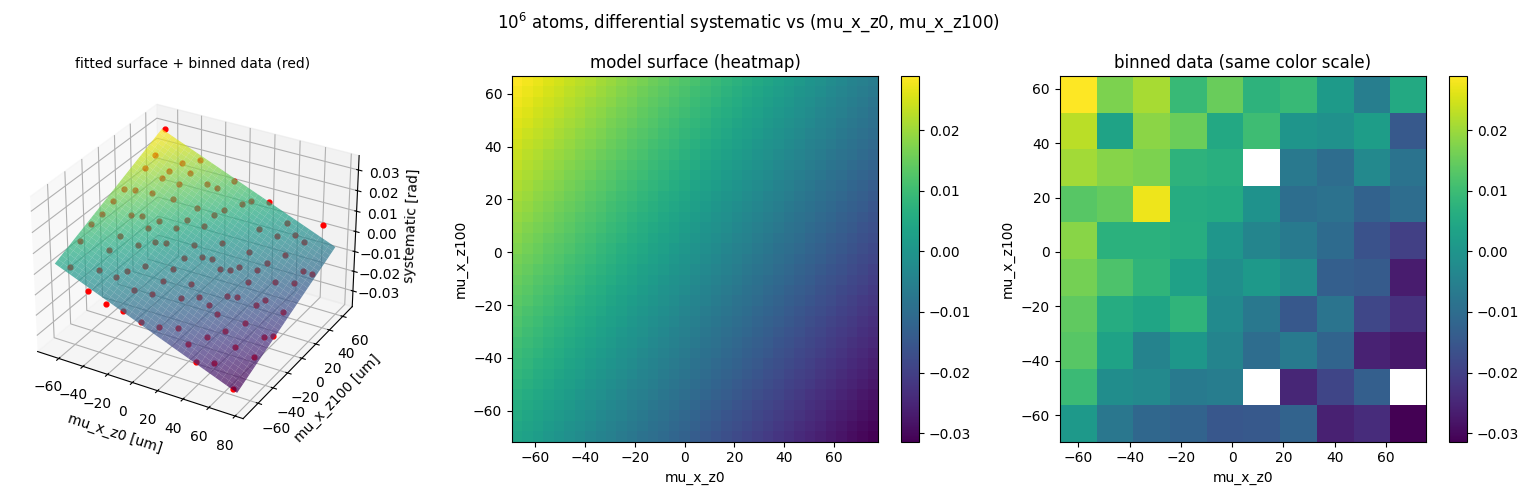

[1e8 fitted (diag only)  ] R2_is=0.882   std[mrad]: raw=13.51  corr(IS)= 1.18


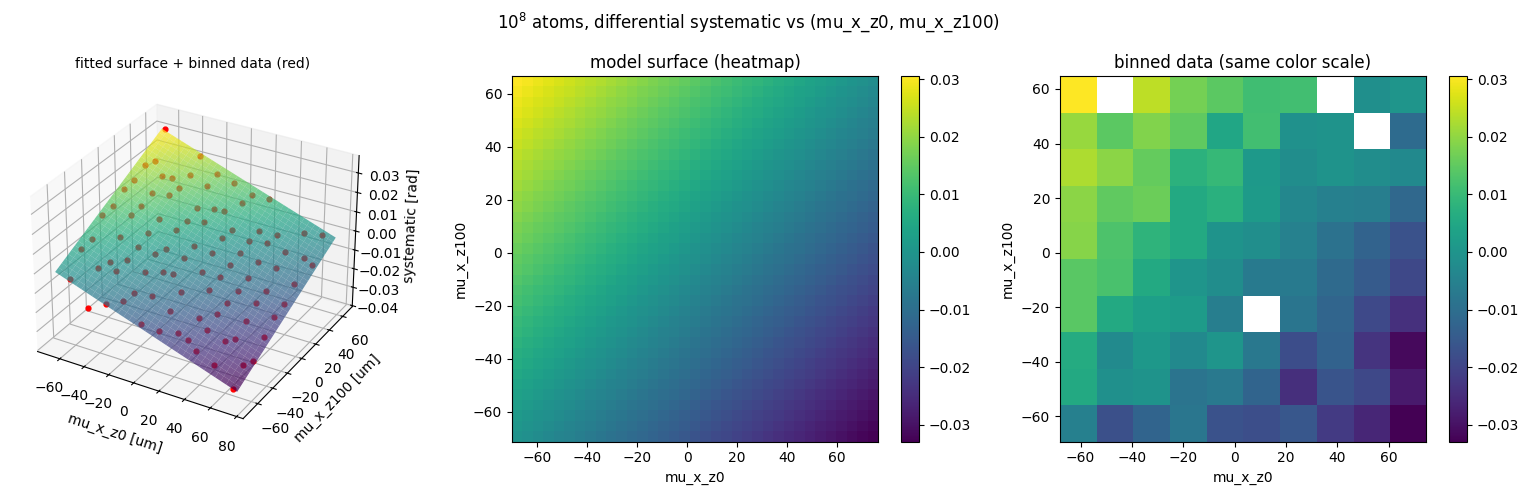

In [12]:
def plot_systematic_surface(diff, diag, f1, f2, dataset_label, title_extra=''):
    pipe, feat_cols = diag['pipe'], diag['feat_cols']
    means = diff[feat_cols].mean()
    q = lambda c, p: diff[c].quantile(p)
    g1 = np.linspace(q(f1, 0.03), q(f1, 0.97), 35)
    g2 = np.linspace(q(f2, 0.03), q(f2, 0.97), 35)
    GG1, GG2 = np.meshgrid(g1, g2)
    Xg = np.tile(means.values, (GG1.size, 1))
    Xg[:, feat_cols.index(f1)] = GG1.ravel()
    Xg[:, feat_cols.index(f2)] = GG2.ravel()
    Zg = pipe.predict(Xg).reshape(GG1.shape)

    sys_data = diag['pipe'].predict(diff[feat_cols].values)
    off = sys_data.mean()
    Zg = Zg - off
    sys_c = sys_data - off

    nb = 10
    bx = np.linspace(q(f1, 0.03), q(f1, 0.97), nb + 1)
    by = np.linspace(q(f2, 0.03), q(f2, 0.97), nb + 1)
    ix = np.clip(np.digitize(diff[f1], bx) - 1, 0, nb - 1)
    iy = np.clip(np.digitize(diff[f2], by) - 1, 0, nb - 1)
    tmp = pd.DataFrame({'ix': ix, 'iy': iy, 'sys': sys_c})
    bmean = tmp.groupby(['ix', 'iy'])['sys'].mean().reset_index()
    bcx, bcy = 0.5*(bx[:-1]+bx[1:]), 0.5*(by[:-1]+by[1:])

    fig = plt.figure(figsize=(16, 5))
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot_surface(GG1*1e6, GG2*1e6, Zg, cmap='viridis', alpha=0.7, linewidth=0)
    ax1.scatter(bcx[bmean.ix]*1e6, bcy[bmean.iy]*1e6, bmean['sys'], color='red', s=12, depthshade=False)
    ax1.set_xlabel(f'{f1} [um]'); ax1.set_ylabel(f'{f2} [um]'); ax1.set_zlabel('systematic [rad]')
    ax1.set_title('fitted surface + binned data (red)', fontsize=10)

    ax2 = fig.add_subplot(1, 3, 2)
    im = ax2.pcolormesh(GG1*1e6, GG2*1e6, Zg, shading='auto', cmap='viridis')
    plt.colorbar(im, ax=ax2); ax2.set_xlabel(f1); ax2.set_ylabel(f2); ax2.set_title('model surface (heatmap)')

    ax3 = fig.add_subplot(1, 3, 3)
    piv = bmean.pivot(index='iy', columns='ix', values='sys')
    im2 = ax3.imshow(piv.values, origin='lower', extent=[bx[0]*1e6, bx[-1]*1e6, by[0]*1e6, by[-1]*1e6],
                     aspect='auto', cmap='viridis', vmin=Zg.min(), vmax=Zg.max())
    plt.colorbar(im2, ax=ax3); ax3.set_xlabel(f1); ax3.set_ylabel(f2); ax3.set_title('binned data (same color scale)')

    plt.suptitle(f'{dataset_label}, differential systematic vs ({f1}, {f2}) {title_extra}', fontsize=12)
    plt.tight_layout(); plt.show()


fit_diags = {}
for key in ['1e6', '1e8']:
    _, diag = differential_pipeline(diffs[key], FIT_FEAT_COLS, label=f'{key} fitted (diag only)', degree=1, do_cv=False)
    fit_diags[key] = diag
    plot_systematic_surface(diffs[key], diag, 'mu_x_z0', 'mu_x_z100', DATASET_LABELS[key])

## 6. Residual distributions: raw vs fitted-feature-corrected vs oracle-corrected

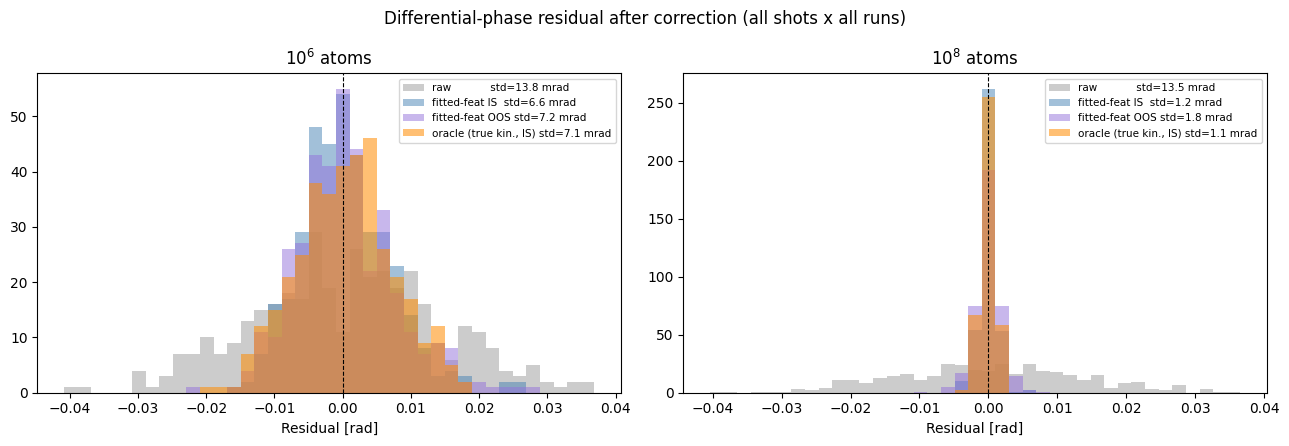

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, key in zip(axes, ['1e6', '1e8']):
    r_raw    = fit_results[key]['res_raw'].values
    r_fit_is = fit_results[key]['res_corr'].values
    r_fit_oos= fit_results[key]['res_oos_corr'].values
    r_oracle = oracle_results[key]['res_corr'].values
    bins = np.linspace(min(r_raw.min(), r_oracle.min()), max(r_raw.max(), r_oracle.max()), 40)
    ax.hist(r_raw,     bins=bins, alpha=0.4,  color='grey',      label=f'raw            std={r_raw.std()*1e3:.1f} mrad')
    ax.hist(r_fit_is,  bins=bins, alpha=0.5,  color='steelblue', label=f'fitted-feat IS  std={r_fit_is.std()*1e3:.1f} mrad')
    ax.hist(r_fit_oos, bins=bins, alpha=0.5,  color='mediumpurple', label=f'fitted-feat OOS std={r_fit_oos.std()*1e3:.1f} mrad')
    ax.hist(r_oracle,  bins=bins, alpha=0.55, color='darkorange',   label=f'oracle (true kin., IS) std={r_oracle.std()*1e3:.1f} mrad')
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_title(DATASET_LABELS[key]); ax.set_xlabel('Residual [rad]'); ax.legend(fontsize=7.5)
plt.suptitle('Differential-phase residual after correction (all shots x all runs)', fontsize=12)
plt.tight_layout(); plt.show()

## 7. Per-run signal $(A_s, A_c)$ recovery — raw / fitted-corrected / oracle-corrected

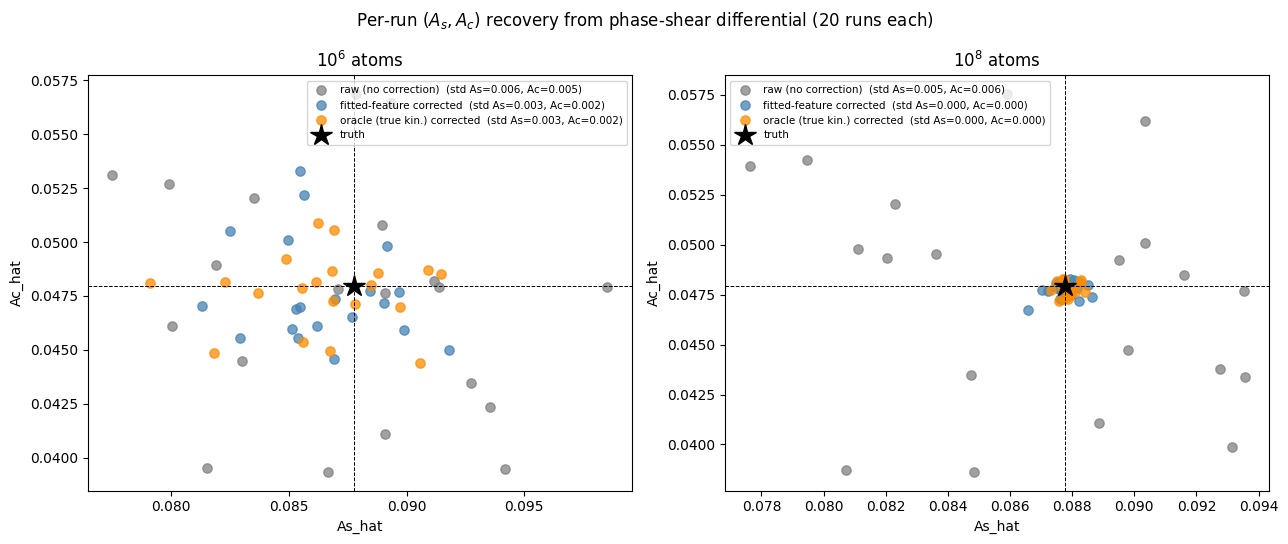

In [9]:
def per_run_beta_fits(diff, f_sig=F_SIG):
    out = {}
    for col, lbl in [('est_raw', 'raw'), ('est_corr', 'corrected')]:
        rows = []
        for run_i, sub in diff.groupby('run'):
            sub = sub.sort_values('shot')
            shots = sub['shot'].values
            A_mat = np.column_stack([np.sin(2*np.pi*f_sig*shots), np.cos(2*np.pi*f_sig*shots)])
            As_h, Ac_h = np.linalg.lstsq(A_mat, sub[col].values, rcond=None)[0]
            rows.append(dict(run=run_i, As_hat=As_h, Ac_hat=Ac_h))
        out[lbl] = pd.DataFrame(rows)
    return out

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, key in zip(axes, ['1e6', '1e8']):
    As_true, Ac_true = dfs[key]['As_true'].iloc[0], dfs[key]['Ac_true'].iloc[0]
    br_raw_fit = per_run_beta_fits(fit_results[key])
    br_oracle  = per_run_beta_fits(oracle_results[key])
    combos = [('raw (no correction)', br_raw_fit['raw'], 'grey'),
              ('fitted-feature corrected', br_raw_fit['corrected'], 'steelblue'),
              ('oracle (true kin.) corrected', br_oracle['corrected'], 'darkorange')]
    for lbl, sub, color in combos:
        ax.scatter(sub['As_hat'], sub['Ac_hat'], s=45, alpha=0.75, color=color,
                   label=f'{lbl}  (std As={sub.As_hat.std():.3f}, Ac={sub.Ac_hat.std():.3f})')
    ax.plot(As_true, Ac_true, 'k*', ms=16, zorder=5, label='truth')
    ax.axvline(As_true, color='k', lw=0.7, ls='--'); ax.axhline(Ac_true, color='k', lw=0.7, ls='--')
    ax.set_xlabel('As_hat'); ax.set_ylabel('Ac_hat'); ax.set_title(DATASET_LABELS[key])
    ax.legend(fontsize=7.5, loc='best')
plt.suptitle('Per-run $(A_s, A_c)$ recovery from phase-shear differential (20 runs each)', fontsize=12)
plt.tight_layout(); plt.show()

## 8. Summary table

dataset             estimator  res_std_mrad  beta_rmse_mrad
    1e6                   raw     13.841246        5.353083
    1e6   fitted-feature (IS)      6.645367        2.628772
    1e6  fitted-feature (OOS)      7.224522             NaN
    1e6 oracle true-kin. (IS)      7.065394        2.641334
    1e8                   raw     13.513676        5.345174
    1e8   fitted-feature (IS)      1.178694        0.461661
    1e8  fitted-feature (OOS)      1.847508             NaN
    1e8 oracle true-kin. (IS)      1.080506        0.325945


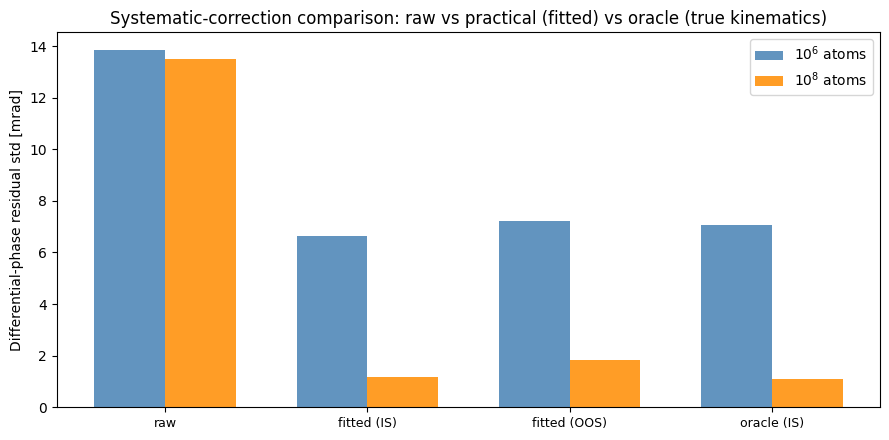

In [10]:
summary_rows = []
for key in ['1e6', '1e8']:
    br_raw_fit = per_run_beta_fits(fit_results[key])
    br_oracle  = per_run_beta_fits(oracle_results[key])
    As_true, Ac_true = dfs[key]['As_true'].iloc[0], dfs[key]['Ac_true'].iloc[0]

    def rmse(sub):
        return float(np.sqrt(((sub.As_hat-As_true)**2 + (sub.Ac_hat-Ac_true)**2).mean() / 2))

    summary_rows += [
        dict(dataset=key, estimator='raw',                  res_std_mrad=fit_results[key].res_raw.std()*1e3,      beta_rmse_mrad=rmse(br_raw_fit['raw'])*1e3),
        dict(dataset=key, estimator='fitted-feature (IS)',   res_std_mrad=fit_results[key].res_corr.std()*1e3,     beta_rmse_mrad=rmse(br_raw_fit['corrected'])*1e3),
        dict(dataset=key, estimator='fitted-feature (OOS)',  res_std_mrad=fit_results[key].res_oos_corr.std()*1e3, beta_rmse_mrad=float('nan')),
        dict(dataset=key, estimator='oracle true-kin. (IS)', res_std_mrad=oracle_results[key].res_corr.std()*1e3,  beta_rmse_mrad=rmse(br_oracle['corrected'])*1e3),
    ]
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(4)
width = 0.35
for i, key in enumerate(['1e6', '1e8']):
    vals = summary_df[summary_df.dataset == key]['res_std_mrad'].values
    ax.bar(x + (i-0.5)*width, vals, width, label=DATASET_LABELS[key], color=DATASET_COLORS[key], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['raw', 'fitted (IS)', 'fitted (OOS)', 'oracle (IS)'], fontsize=9)
ax.set_ylabel('Differential-phase residual std [mrad]')
ax.set_title('Systematic-correction comparison: raw vs practical (fitted) vs oracle (true kinematics)')
ax.legend()
plt.tight_layout(); plt.show()